In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [59]:
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

lr = 0.01
epochs = 30
batch_size = 1024

In [60]:
dataset_path = "data/creditcard.csv"
df = pd.read_csv(dataset_path)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [61]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [62]:
dataset_arr = df.to_numpy()
X, y = dataset_arr[:, :-1].astype(np.float64), dataset_arr[:, -1].astype(np.uint8)

In [63]:
intercept = np.ones((X.shape[0], 1))
X_b = np.concatenate((intercept, X), axis=1)
print(X_b.shape)

(284807, 31)


In [64]:
n_classes = np.unique(y, axis=0).shape[0]
n_samples = y.shape[0]

y_encoded = np.array([np.zeros(n_classes) for _ in range(n_samples)])
y_encoded[np.arange(n_samples), y] = 1

In [65]:
X_train, X_val, y_train, y_val = train_test_split(
    X_b, y_encoded,
    test_size=val_size,
    random_state=random_state,
    shuffle=is_shuffle
)


X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size=test_size,
    random_state=random_state,
    shuffle=is_shuffle
)

In [66]:
normalizer = StandardScaler()
X_train[:, 1:] = normalizer.fit_transform(X_train[:, 1:])
X_val[:, 1:] = normalizer.transform(X_val[:, 1:])
X_test[:, 1:] = normalizer.transform(X_test[:, 1:])

In [67]:
smote = SMOTE(random_state=random_state, sampling_strategy="minority")
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train[:, 1:], np.argmax(y_train, axis=1)
)

In [68]:
intercept_balanced = np.ones((X_train_balanced.shape[0], 1))
X_train = np.concatenate((intercept_balanced, X_train_balanced), axis=1)

y_train = np.zeros((y_train_balanced.shape[0], n_classes))
y_train[np.arange(y_train_balanced.shape[0]), y_train_balanced] = 1

print(f"Balanced training samples: {X_train.shape[0]}")
print(f"Class distribution: {np.bincount(y_train_balanced)}")

Balanced training samples: 398002
Class distribution: [199001 199001]


In [69]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))

    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [70]:
def predict(X, theta):
    z = X @ theta
    y_hat = softmax(z)

    return y_hat

In [71]:
def compute_loss(y_hat, y):
    n = y.shape[0]
    y_hat = np.clip(y_hat, 1e-15, 1.0 - 1e-15)

    return (-np.sum(y * np.log(y_hat))) / n

In [72]:
def compute_gradient(X, y, y_hat):
    n = y.shape[0]

    return (X.T @ (y_hat - y)) / n

In [73]:
def update_theta(theta, gradient, lr):
    return theta - gradient*lr

In [74]:
def compute_accuracy(X, y, theta):
    preds = np.argmax(predict(X, theta), axis=1)
    trues = np.argmax(y, axis=1)

    return np.sum(preds == trues) / y.shape[0]

In [75]:
n_features = X_train.shape[1]
np.random.seed(random_state)
theta = np.random.uniform(size=(n_features, n_classes))

train_accs = []
train_losses = []
val_accs = []
val_losses = []

for epoch in range(epochs):
    train_batch_losses = []
    train_batch_accs = []
    val_batch_losses = []
    val_batch_accs = []

    for i in range(0, X_train.shape[0], batch_size):
        X_i = X_train[i:i+batch_size]
        y_i = y_train[i:i+batch_size]

        y_hat = predict(X_i, theta)
        train_loss = compute_loss(y_hat, y_i)

        gradient = compute_gradient(X_i, y_i, y_hat)
        theta = update_theta(theta, gradient, lr)

        train_batch_losses.append(train_loss)
        train_acc = compute_accuracy(X_train, y_train, theta)
        train_batch_accs.append(train_acc)
        
        y_val_hat = predict(X_val, theta)
        val_loss = compute_loss(y_val_hat, y_val)
        val_batch_losses.append(val_loss)

        val_acc = compute_accuracy(X_val, y_val, theta)
        val_batch_accs.append(val_acc)
        
    train_batch_loss = sum(train_batch_losses) / len(train_batch_losses)
    val_batch_loss = sum(val_batch_losses) / len(val_batch_losses)
    train_batch_acc = sum(train_batch_accs) / len(train_batch_accs)
    val_batch_acc = sum(val_batch_accs) / len(val_batch_accs)
        
    train_losses.append(train_batch_loss)
    val_losses.append(val_batch_loss)
    train_accs.append(train_batch_acc)
    val_accs.append(val_batch_acc)
        
    print(f"\nEPOCH {epoch + 1}:\tTraining loss: {train_batch_loss:.3f}\tValidation loss: {val_batch_loss:.3f}")


EPOCH 1:	Training loss: 0.316	Validation loss: 0.401

EPOCH 2:	Training loss: 0.197	Validation loss: 0.235

EPOCH 3:	Training loss: 0.162	Validation loss: 0.181

EPOCH 4:	Training loss: 0.149	Validation loss: 0.159

EPOCH 5:	Training loss: 0.143	Validation loss: 0.148

EPOCH 6:	Training loss: 0.139	Validation loss: 0.141

EPOCH 7:	Training loss: 0.137	Validation loss: 0.136

EPOCH 8:	Training loss: 0.135	Validation loss: 0.132

EPOCH 9:	Training loss: 0.134	Validation loss: 0.129

EPOCH 10:	Training loss: 0.133	Validation loss: 0.127

EPOCH 11:	Training loss: 0.132	Validation loss: 0.125

EPOCH 12:	Training loss: 0.131	Validation loss: 0.124

EPOCH 13:	Training loss: 0.131	Validation loss: 0.123

EPOCH 14:	Training loss: 0.130	Validation loss: 0.122

EPOCH 15:	Training loss: 0.130	Validation loss: 0.121

EPOCH 16:	Training loss: 0.130	Validation loss: 0.120

EPOCH 17:	Training loss: 0.129	Validation loss: 0.119

EPOCH 18:	Training loss: 0.129	Validation loss: 0.119

EPOCH 19:	Training

In [76]:
preds = np.argmax(predict(X_val, theta), axis=1)
trues = np.argmax(y_val, axis=1)

TP = np.sum((preds==1)&(trues==1))
FP = np.sum((preds==1)&(trues==0))
FN = np.sum((preds==0)&(trues==1))
TN = np.sum((preds==0)&(trues==0))

print(TP, FP, FN, TN)

78 1973 6 54905


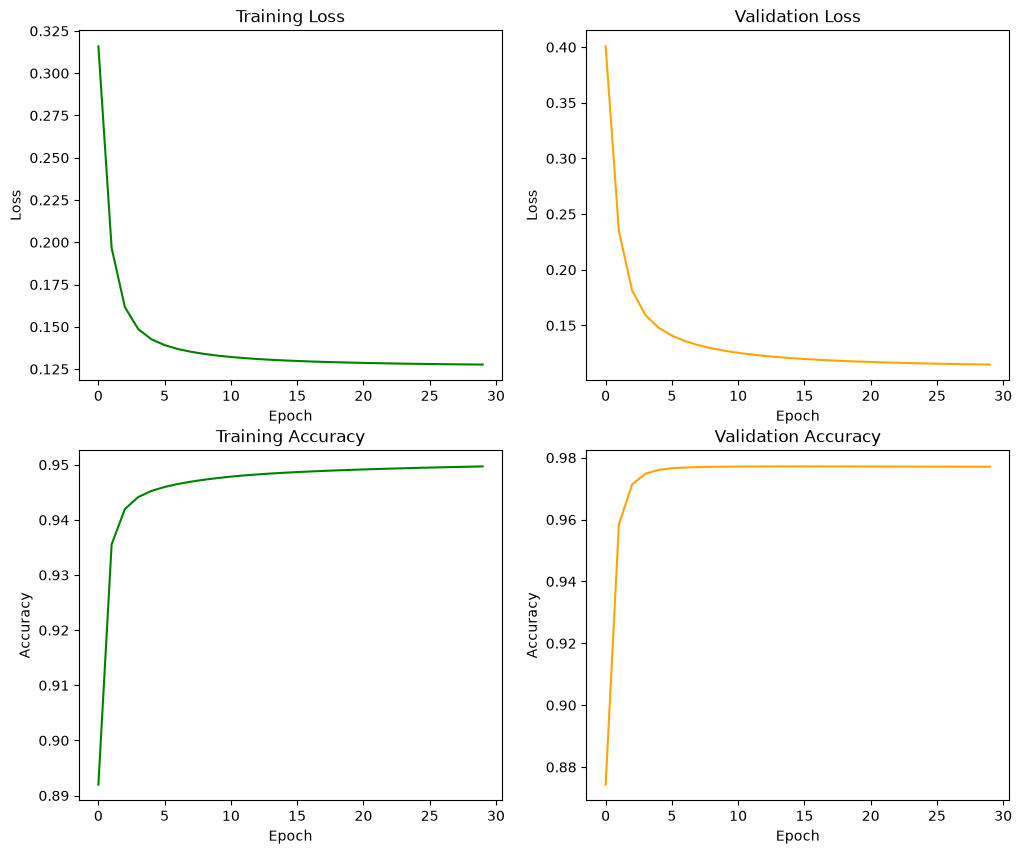

In [77]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0, 0].plot(train_losses, color="green")
ax[0, 0].set(xlabel="Epoch", ylabel="Loss")
ax[0, 0].set_title("Training Loss")

ax[0, 1].plot(val_losses, color="orange")
ax[0, 1].set(xlabel="Epoch", ylabel="Loss")
ax[0, 1].set_title("Validation Loss")

ax[1, 0].plot(train_accs, color="green")
ax[1, 0].set(xlabel="Epoch", ylabel="Accuracy")
ax[1, 0].set_title("Training Accuracy")

ax[1, 1].plot(val_accs, color="orange")
ax[1, 1].set(xlabel="Epoch", ylabel="Accuracy")
ax[1, 1].set_title("Validation Accuracy")

plt.show()